In [1]:
import xarray as xr
import sys, os
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from cloudpathlib import AnyPath

# Local Imports
curdir = os.getcwd()
#print(curdir)
sys.path.insert(0, curdir+"/../../../data_processing")
from ceres_ebaf import *

sys.path.insert(0, curdir+"/../../../visualization")
from ceres_ebaf_plotting import *

base_path = AnyPath("/Users/mawa7160/dev/data/CERES/EBAF/")
full_ebaf_filename = "CERES_EBAF-TOA_Ed4.2_Subset_200003-202402.nc"
global_ebaf_filename = "CERES_EBAF-TOA_Ed4.2_Subset_200003-202402_global.nc"

plt.rcParams['figure.figsize'] = [10, 3.5]

In [2]:
# Load the data
full_data_path = base_path / full_ebaf_filename
global_average_data_path = base_path / global_ebaf_filename

ds = xr.open_dataset(full_data_path)
ds_global = xr.open_dataset(global_average_data_path)

## Single Month Example

In [3]:
feb_24_solar = ds["solar_mon"].sel(time="2021-02-15")
feb_24_solar_global = ds_global["gsolar_mon"].sel(time="2021-02-15")

In [4]:
# Calculate the global average using three different methods
ceres_produced = feb_24_solar_global.values
no_weighting = apply_spatial_weights(feb_24_solar, method=0).values
geodetic_produced = apply_spatial_weights(feb_24_solar, method=1).values
cosine_produced = apply_spatial_weights(feb_24_solar, method=2).values

# Use xarray to average the lat lon data into a global average
xarray_global = feb_24_solar.mean(dim=["lat","lon"])

In [5]:
print(f"Global Average from CERES: {ceres_produced}")
print(f"Global Average from Geodetic: {geodetic_produced}")
print(f"Global Average from Cosine: {cosine_produced}")
print(f"Global Average from No Weighting: {no_weighting}")
print(f"Global Average from Xarray mean: {xarray_global.values}")

Global Average from CERES: 348.5010070800781
Global Average from Geodetic: 348.50073276019106
Global Average from Cosine: 348.80890770153206
Global Average from No Weighting: 299.43079260133527
Global Average from Xarray mean: 299.4308166503906


In [6]:
print(f"Percent Difference from CERES to Geodetic: {np.abs(ceres_produced - geodetic_produced) / ceres_produced * 100}")
print(f"Percent Difference from CERES to Cosine: {np.abs(ceres_produced - cosine_produced) / ceres_produced * 100}")
print(f"Percent Difference from CERES to No Weighting: {np.abs(ceres_produced - no_weighting) / ceres_produced * 100}")

Percent Difference from CERES to Geodetic: 7.87142308044775e-05
Percent Difference from CERES to Cosine: 0.08834999474856324
Percent Difference from CERES to No Weighting: 14.080365187429017


## Single Year Example

In [28]:
full_data_2021_raw = ds["solar_mon"].sel(time=slice("2020-12-15", "2022-01-15"))
full_data_2021_global = ds_global["gsolar_mon"].sel(time=slice("2020-12-15", "2022-01-15"))

time_method = 2
ceres_2021 = apply_time_averaging(full_data_2021_global, averaging_method=time_method)
full_data_2021 = apply_time_averaging(full_data_2021_raw, averaging_method=time_method)

In [29]:
# Calculate the global average using three different methods
ceres_2021_spatial_avg = ceres_2021
no_weighting_2021_spatial_avg = apply_spatial_weights(full_data_2021, method=0)
geodetic_2021_spatial_avg = apply_spatial_weights(full_data_2021, method=1)
cosine_2021_spatial_avg = apply_spatial_weights(full_data_2021, method=2)

In [30]:
print(f"Global Average from CERES: {ceres_2021_spatial_avg.values[0]}")
print(f"Global Average from Geodetic: {geodetic_2021_spatial_avg.values[0]}")
print(f"Global Average from Cosine: {cosine_2021_spatial_avg.values[0]}")
print(f"Global Average from No Weighting: {no_weighting_2021_spatial_avg.values[0]}")

Global Average from CERES: 340.15509033203125
Global Average from Geodetic: 340.15510520849926
Global Average from Cosine: 340.43467598741677
Global Average from No Weighting: 298.501675406091


In [31]:
print(f"Percent Difference from CERES to Geodetic: {np.abs(ceres_2021_spatial_avg.values[0] - geodetic_2021_spatial_avg.values[0]) / ceres_2021_spatial_avg.values[0] * 100}")
print(f"Percent Difference from CERES to Cosine: {np.abs(ceres_2021_spatial_avg.values[0] - cosine_2021_spatial_avg.values[0]) / ceres_2021_spatial_avg.values[0] * 100}")
print(f"Percent Difference from CERES to No Weighting: {np.abs(ceres_2021_spatial_avg.values[0] - no_weighting_2021_spatial_avg.values[0]) / ceres_2021_spatial_avg.values[0] * 100}")

Percent Difference from CERES to Geodetic: 4.373436834436143e-06
Percent Difference from CERES to Cosine: 0.08219358267213023
Percent Difference from CERES to No Weighting: 12.245418666315304


Text(0.5, 1.0, 'Comparison of Spatial Averaging Methods of Incoming Solar Insolation in 2021')

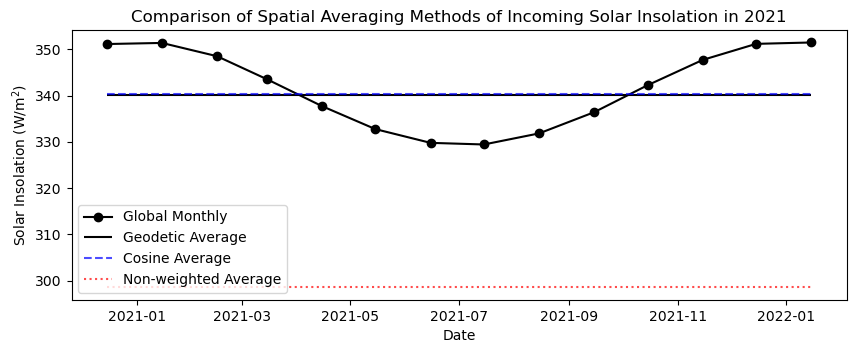

In [32]:
plt.plot(full_data_2021_raw.time, apply_spatial_weights(full_data_2021_raw), "-ok", label="Global Monthly")
plt.hlines(geodetic_2021_spatial_avg.values[0], full_data_2021_raw.time[0], full_data_2021_raw.time[-1], 'k', label="Geodetic Average")
plt.hlines(cosine_2021_spatial_avg.values[0], full_data_2021_raw.time[0], full_data_2021_raw.time[-1], 'b', label="Cosine Average", alpha=0.7, linestyles="dashed")
plt.hlines(no_weighting_2021_spatial_avg.values[0], full_data_2021_raw.time[0], full_data_2021_raw.time[-1], 'r', label="Non-weighted Average", alpha=0.7, linestyles="dotted")
plt.legend()
plt.ylabel("Solar Insolation (W/m$^2$)")
plt.xlabel("Date")
plt.title("Comparison of Spatial Averaging Methods of Incoming Solar Insolation in 2021")

# Single Year Plotting

Text(0.5, 1.0, 'Comparison of Incoming Solar Insolation in 2021')

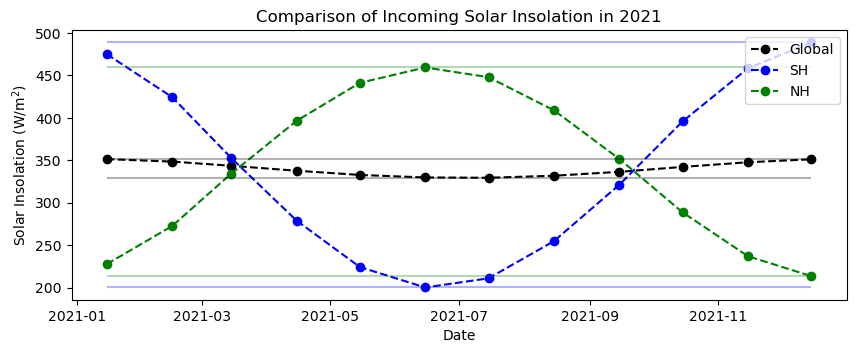

In [16]:
sh = apply_spatial_weights(full_data_2021_raw, low_lat=-90, high_lat=0)
nh = apply_spatial_weights(full_data_2021_raw, low_lat=0, high_lat=90)
glob = apply_spatial_weights(full_data_2021_raw)
plt.plot(full_data_2021_raw.time, glob, "--ok", label="Global")
plt.plot(full_data_2021_raw.time, sh, "--ob", label="SH")
plt.plot(full_data_2021_raw.time, nh, "--og", label="NH")
max_style = "solid"#(0, (3,5,1,5,1,5))
max_alpha = 0.3
plt.hlines(nh.max(), full_data_2021_raw.time[0], full_data_2021_raw.time[-1],"g", linestyles=max_style, alpha=max_alpha)
plt.hlines(nh.min(), full_data_2021_raw.time[0], full_data_2021_raw.time[-1], "g", linestyles=max_style, alpha=max_alpha)
plt.hlines(sh.max(), full_data_2021_raw.time[0], full_data_2021_raw.time[-1], "b", linestyles=max_style, alpha=max_alpha)
plt.hlines(sh.min(), full_data_2021_raw.time[0], full_data_2021_raw.time[-1], "b", linestyles=max_style, alpha=max_alpha)
plt.hlines(glob.max(), full_data_2021_raw.time[0], full_data_2021_raw.time[-1], "k", linestyles=max_style, alpha=max_alpha)
plt.hlines(glob.min(), full_data_2021_raw.time[0], full_data_2021_raw.time[-1], "k", linestyles=max_style, alpha=max_alpha)
plt.legend()
plt.ylabel("Solar Insolation (W/m$^2$)")
plt.xlabel("Date")
plt.title("Comparison of Incoming Solar Insolation in 2021")

In [15]:
print(f"2021 Average TOA Solar Insolation - Global: {apply_time_averaging(glob, averaging_method=2).values[0]}")
print(f"2021 Average TOA Solar Insolation - NH: {apply_time_averaging(nh, averaging_method=2).values[0]}")
print(f"2021 Average TOA Solar Insolation - SH: {apply_time_averaging(sh, averaging_method=2).values[0]}")
print()
print(f"2021 Max TOA Solar Insolation - Global: {glob.max().values}")
print(f"2021 Max TOA Solar Insolation - NH: {nh.max().values}")
print(f"2021 Max TOA Solar Insolation - SH: {sh.max().values}")
print()
print(f"2021 Min TOA Solar Insolation - Global: {glob.min().values}")
print(f"2021 Min TOA Solar Insolation - NH: {nh.min().values}")
print(f"2021 Min TOA Solar Insolation - SH: {sh.min().values}")


2021 Average TOA Solar Insolation - Global: 340.1596544739491
2021 Average TOA Solar Insolation - NH: 340.1615536903119
2021 Average TOA Solar Insolation - SH: 340.1577552537761

2021 Max TOA Solar Insolation - Global: 351.371356175351
2021 Max TOA Solar Insolation - NH: 459.4654088665386
2021 Max TOA Solar Insolation - SH: 488.9142241762828

2021 Min TOA Solar Insolation - Global: 329.41595397455416
2021 Min TOA Solar Insolation - NH: 213.42616862710344
2021 Min TOA Solar Insolation - SH: 200.07241939633994


## Multi-Year Example

In [11]:
full_data_2010_2014 = ds["solar_mon"].sel(time=slice("2010-1-15", "2013-12-15"))
full_data_2010_2014_global = ds_global["gsolar_mon"].sel(time=slice("2010-01-15", "2013-12-15"))

full_lifetime = ds["solar_mon"]
full_lifetime_global = ds_global["gsolar_mon"]

In [12]:
time_method = 2
ceres_2010_2014 = apply_time_averaging(full_data_2010_2014_global, averaging_method=time_method)
full_data_2010_2014 = apply_time_averaging(full_data_2010_2014, averaging_method=time_method)

ceres_lifetime = apply_time_averaging(full_lifetime_global, averaging_method=time_method)
full_lifetime = apply_time_averaging(full_lifetime, averaging_method=time_method)

In [13]:
# Calculate the global average using three different methods
ceres_2010_2014_spatial_avg = ceres_2010_2014
no_weighting_2010_2014_spatial_avg = apply_spatial_weights(full_data_2010_2014, method=0)
geodetic_2010_2014_spatial_avg = apply_spatial_weights(full_data_2010_2014, method=1)
cosine_2010_2014_spatial_avg = apply_spatial_weights(full_data_2010_2014, method=2)

ceres_lifetime_spatial_avg = ceres_lifetime
no_weighting_lifetime_spatial_avg = apply_spatial_weights(full_lifetime, method=0)
geodetic_lifetime_spatial_avg = apply_spatial_weights(full_lifetime, method=1)
cosine_lifetime_spatial_avg = apply_spatial_weights(full_lifetime, method=2)

In [14]:
print(f"Global Average from CERES 2010-2014: {ceres_2010_2014_spatial_avg.values[0]}")
print(f"Global Average from Geodetic 2010-2014: {geodetic_2010_2014_spatial_avg.values[0]}")
print(f"Global Average from Cosine 2010-2014: {cosine_2010_2014_spatial_avg.values[0]}")
print(f"Global Average from No Weighting 2010-2014: {no_weighting_2010_2014_spatial_avg.values[0]}")

Global Average from CERES 2010-2014: 340.0933532714844
Global Average from Geodetic 2010-2014: 340.0933521280317
Global Average from Cosine 2010-2014: 340.37286480878794
Global Average from No Weighting 2010-2014: 298.4494998851823


In [15]:
print(f"Global Average from CERES Lifetime: {ceres_lifetime_spatial_avg.values[0]}")
print(f"Global Average from Geodetic Lifetime: {geodetic_lifetime_spatial_avg.values[0]}")
print(f"Global Average from Cosine Lifetime: {cosine_lifetime_spatial_avg.values[0]}")
print(f"Global Average from No Weighting Lifetime: {no_weighting_lifetime_spatial_avg.values[0]}")

Global Average from CERES Lifetime: 340.2904968261719
Global Average from Geodetic Lifetime: 340.2904945791789
Global Average from Cosine Lifetime: 340.57013909520396
Global Average from No Weighting Lifetime: 298.628148206075


In [16]:
print(f"Percent Difference from CERES to Geodetic 2010-2014: {np.abs(ceres_2010_2014_spatial_avg.values[0] - geodetic_2010_2014_spatial_avg.values[0]) / ceres_2010_2014_spatial_avg.values[0] * 100}")
print(f"Percent Difference from CERES to Cosine 2010-2014: {np.abs(ceres_2010_2014_spatial_avg.values[0] - cosine_2010_2014_spatial_avg.values[0]) / ceres_2010_2014_spatial_avg.values[0] * 100}")
print(f"Percent Difference from CERES to No Weighting 2010-2014: {np.abs(ceres_2010_2014_spatial_avg.values[0] - no_weighting_2010_2014_spatial_avg.values[0]) / ceres_2010_2014_spatial_avg.values[0] * 100}")

Percent Difference from CERES to Geodetic 2010-2014: 3.3621729243172475e-07
Percent Difference from CERES to Cosine 2010-2014: 0.08218670980036435
Percent Difference from CERES to No Weighting 2010-2014: 12.244830128467479


In [17]:
print(f"Percent Difference from CERES to Geodetic Lifetime: {np.abs(ceres_lifetime_spatial_avg.values[0] - geodetic_lifetime_spatial_avg.values[0]) / ceres_lifetime_spatial_avg.values[0] * 100}")
print(f"Percent Difference from CERES to Cosine Lifetime: {np.abs(ceres_lifetime_spatial_avg.values[0] - cosine_lifetime_spatial_avg.values[0]) / ceres_lifetime_spatial_avg.values[0] * 100}")
print(f"Percent Difference from CERES to No Weighting Lifetime: {np.abs(ceres_lifetime_spatial_avg.values[0] - no_weighting_lifetime_spatial_avg.values[0]) / ceres_lifetime_spatial_avg.values[0] * 100}")

Percent Difference from CERES to Geodetic Lifetime: 6.603161034460698e-07
Percent Difference from CERES to Cosine Lifetime: 0.08217751351867127
Percent Difference from CERES to No Weighting Lifetime: 12.243171351734492
